# Gradient Descent in Two Variables — Part 1 (Motivation)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture extending **gradient descent to
several variables** (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- how the 1-variable gradient-descent idea **generalizes to two (or more) variables**
- a recap of the **sauna** problem — reach the coldest spot in a room
- the **naive** approach: sample a few directions, step toward the coldest, repeat
- the caveat — *how do you pick good directions?* — and the answer: the **gradient**
- a preview of the smart, gradient-based update

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Gradient Descent in One Variable — Parts 1–3* and *Optimization with Gradients: An
Example*.

## 1. Introduction

> *"Now that you learned gradient descent for one variable, let's learn it for more
> variables. We'll start at the bottom and work our way up to the complete algorithm."*

In one variable, gradient descent stepped **opposite the slope**. With two variables we
need to step in the best **direction** in the plane — and the gradient will tell us which.

We reuse the **sauna** example from earlier this week: at each position $(x,y)$ the
temperature is a function $T(x,y)$, and the goal is to reach the **coldest** spot.

After this notebook you will be able to:

- describe the iterative search for a minimum in 2D
- see why choosing directions at random is wasteful
- understand that the gradient gives the best direction (set up for the full algorithm)

## 2. Recap: the sauna and the analytical method

Earlier we solved the sauna problem **analytically** — compute the partial derivatives and
set them to zero ($\nabla T = 0$). For

$$
T(x,y) = 85 - \frac{1}{90}\,x^2(x-6)\,y^2(y-6),
$$

that gave the coldest point $(4, 4)$ with $T = 73.6$.

> *"The goal now is to find some alternative way to solve this problem using gradients,
> just as you did for a one-variable function."*

Now we want an **iterative** method instead — useful when $\nabla T = 0$ is too hard to
solve directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def T(x, y):
    return 85 - (1/90) * x**2 * (x - 6) * y**2 * (y - 6)

# the coldest point we found analytically
print("T(4, 4) =", round(T(4, 4), 3), " (analytical minimum)")

T(4, 4) = 73.622  (analytical minimum)


## 3. The naive approach: random steps

> *"You take four random steps in four directions and see which one gets you to the
> coldest place. You move a step in that direction, then repeat — and you iterate until
> you reach the coldest place, or somewhere close."*

So a first attempt:

1. From your current position, try a few directions (e.g. four).
2. Evaluate the temperature a small step away in each.
3. Move to the **coldest** of them.
4. Repeat.

In [2]:
def naive_descent(T, start, step=0.3, n_dirs=4, max_iter=100, seed=0):
    rng = np.random.default_rng(seed)
    pos = np.array(start, dtype=float)
    path = [pos.copy()]
    for _ in range(max_iter):
        # n_dirs random unit directions
        angles = rng.uniform(0, 2*np.pi, n_dirs)
        dirs = np.stack([np.cos(angles), np.sin(angles)], axis=1)
        candidates = pos + step * dirs
        temps = np.array([T(c[0], c[1]) for c in candidates])
        best = candidates[np.argmin(temps)]
        if T(*best) < T(*pos):     # only move if it gets colder
            pos = best
            path.append(pos.copy())
        else:
            break                   # no colder neighbour found -> stop
    return pos, np.array(path)

final, path = naive_descent(T, start=(1.0, 1.0))
print(f"Naive descent ended at ({final[0]:.3f}, {final[1]:.3f}), T = {T(*final):.3f}")
print(f"Steps taken: {len(path) - 1}")

Naive descent ended at (3.990, 3.709), T = 73.795
Steps taken: 19


### Visualizing the naive path on the sauna heat-map

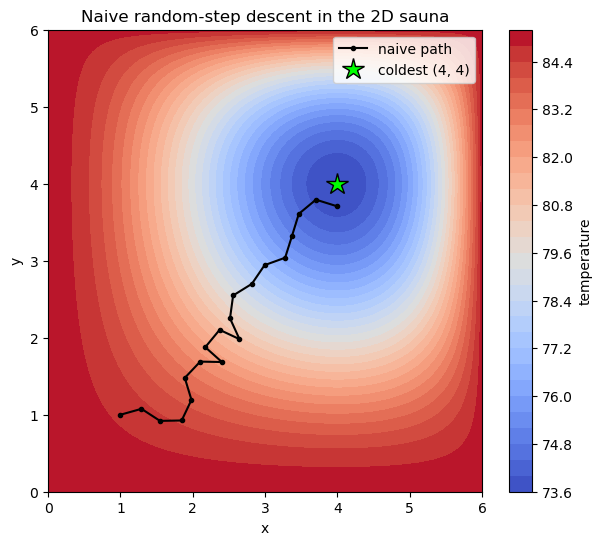

In [3]:
gx = np.linspace(0, 6, 200)
gy = np.linspace(0, 6, 200)
X, Y = np.meshgrid(gx, gy)
Z = T(X, Y)

plt.figure(figsize=(7, 6))
hm = plt.contourf(X, Y, Z, levels=30, cmap="coolwarm")
plt.colorbar(hm, label="temperature")
plt.plot(path[:, 0], path[:, 1], "o-", color="black", markersize=3, label="naive path")
plt.plot(4, 4, "*", color="lime", markersize=16, markeredgecolor="black",
         label="coldest (4, 4)")
plt.title("Naive random-step descent in the 2D sauna")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## 4. The caveat — and the smart fix

> *"There's a small caveat: how do you pick the directions in which to take steps? Is
> there a smart way? Just like with one variable, there is — and it is using derivatives,
> except this time using **gradients**."*

Random directions waste effort. The **gradient** $\nabla T = (T_x, T_y)$ points in the
direction of **steepest increase**, so to get **colder fastest** we step in the
**opposite** direction, $-\nabla T$. That is the 2D analogue of the 1D rule
$x_{\text{new}} = x_{\text{old}} - \alpha f'(x)$:

$$
\begin{bmatrix} x_k \\ y_k \end{bmatrix}
=
\begin{bmatrix} x_{k-1} \\ y_{k-1} \end{bmatrix}
- \alpha \,\nabla T(x_{k-1}, y_{k-1}).
$$

The next lecture develops this full algorithm. Here is a quick **preview** showing how
much more directly the gradient heads for the cold spot.

Gradient descent ended at (4.000, 4.000), T = 73.622 in 17 steps


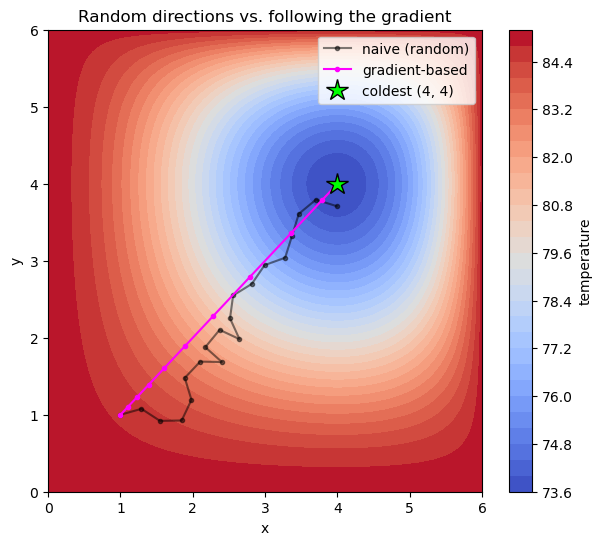

In [4]:
# preview of gradient-based descent (full algorithm is the next lecture)
def grad_T(x, y):
    Tx = -(1/90) * (3*x**2 - 12*x) * y**2 * (y - 6)
    Ty = -(1/90) * x**2 * (x - 6) * (3*y**2 - 12*y)
    return np.array([Tx, Ty])

def gradient_descent_2d(grad, start, alpha=0.2, max_iter=200, tol=1e-6):
    pos = np.array(start, dtype=float)
    path = [pos.copy()]
    for _ in range(max_iter):
        step = alpha * grad(*pos)
        pos = pos - step
        path.append(pos.copy())
        if np.linalg.norm(step) < tol:
            break
    return pos, np.array(path)

g_final, g_path = gradient_descent_2d(grad_T, start=(1.0, 1.0))
print(f"Gradient descent ended at ({g_final[0]:.3f}, {g_final[1]:.3f}), "
      f"T = {T(*g_final):.3f} in {len(g_path)-1} steps")

plt.figure(figsize=(7, 6))
hm = plt.contourf(X, Y, Z, levels=30, cmap="coolwarm")
plt.colorbar(hm, label="temperature")
plt.plot(path[:, 0], path[:, 1], "o-", color="black", markersize=3,
         alpha=0.5, label="naive (random)")
plt.plot(g_path[:, 0], g_path[:, 1], "o-", color="magenta", markersize=3,
         label="gradient-based")
plt.plot(4, 4, "*", color="lime", markersize=16, markeredgecolor="black",
         label="coldest (4, 4)")
plt.title("Random directions vs. following the gradient")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.show()

## 5. Exercises

### Basic
1. In words, what is the goal of gradient descent in the sauna problem?
2. Why is choosing step directions at random inefficient?

### Intermediate
3. Run the naive descent from a different starting point (e.g. $(5, 1)$) and compare the
   number of steps and final temperature.
4. Increase the number of sampled directions from 4 to 16 in the naive method. Does it
   reach a colder point?

### Advanced
5. Which direction gives the fastest decrease of $T$ at a point, and how is it related to
   $\nabla T$?
6. Write the 2D gradient-descent update rule and explain why it uses $-\nabla T$ rather
   than $+\nabla T$.

## 6. Solutions / Checks

In [5]:
# 3. different start
f3, p3 = naive_descent(T, start=(5.0, 1.0))
print(f"3. start (5,1) -> ({f3[0]:.3f}, {f3[1]:.3f}), T={T(*f3):.3f}, steps={len(p3)-1}")

# 4. more directions
f4, p4 = naive_descent(T, start=(1.0, 1.0), n_dirs=16)
print(f"4. 16 dirs -> ({f4[0]:.3f}, {f4[1]:.3f}), T={T(*f4):.3f}, steps={len(p4)-1}")

print("5. The steepest-decrease direction is -∇T (negative gradient); ∇T points to "
      "steepest increase.")
print("6. Update: [x_k, y_k] = [x_(k-1), y_(k-1)] - α ∇T. We subtract ∇T because ∇T "
      "points uphill, and we want to go downhill (toward the minimum).")

3. start (5,1) -> (4.963, 1.298), T=82.752, steps=1
4. 16 dirs -> (3.911, 3.919), T=73.653, steps=14
5. The steepest-decrease direction is -∇T (negative gradient); ∇T points to steepest increase.
6. Update: [x_k, y_k] = [x_(k-1), y_(k-1)] - α ∇T. We subtract ∇T because ∇T points uphill, and we want to go downhill (toward the minimum).


## 7. Conclusion

- Gradient descent generalizes naturally from one variable to **two or more**.
- A purely **random** search (sample directions, step toward the coldest) works but wastes
  effort on poor directions.
- The **gradient** $\nabla T$ points to steepest increase, so stepping along $-\nabla T$ is
  the smart, efficient choice:

$$
\mathbf{x}_k = \mathbf{x}_{k-1} - \alpha\,\nabla T(\mathbf{x}_{k-1}).
$$

- The next lecture builds this into the complete multivariable gradient-descent algorithm.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/gradient_4.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture introducing **gradient descent in two variables**. Key spoken
points, lightly cleaned:

> Having learned gradient descent for one variable, we extend it to more variables,
> building up to the complete algorithm. Recall the sauna temperature example with two
> variables, where the goal is to reach the coldest place; previously we solved it
> analytically by setting the partial derivatives to zero, and now we want an alternative
> using gradients, as in the one-variable case. A naive idea: from your position, take a
> few random steps in different directions, see which reaches the coldest place, move
> there, and iterate until you reach (or get close to) the coldest spot. The caveat is how
> to choose the directions — and, just like in one variable, the smart way uses
> derivatives, this time gradients.